# Phone-call-only K curve — L2-SP vs ANIL vs the lookup

In [1]:
import os, sys, json, pathlib, warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

_SRC = pathlib.Path.cwd()
for _ in range(6):
    if (_SRC / "ProVoice").is_dir():
        break
    _SRC = _SRC.parent
sys.path.insert(0, str(_SRC))

%matplotlib inline
pd.set_option("display.width", 220)
warnings.filterwarnings("ignore", category=FutureWarning)

ROOT = _SRC.parent
# PCK_DIR exists so this notebook can be smoke-tested against a synthetic table
# without writing into results/. Unset, it is the real path.
PCK = pathlib.Path(os.environ.get("PCK_DIR", ROOT / "results/phone_call_k_curve"))
POOLED = pathlib.Path(os.environ.get("POOLED_DIR", ROOT / "results/arm_comparison_v2"))
GRAD_OK = 1e-3        # phone_call_k_curve.GRAD_NORM_WARN

ARMS = {"l2sp": "L2-SP (population init)", "anil": "ANIL (meta-learned init)"}
COL = {"l2sp": "tab:blue", "anil": "tab:red", "lookup": "k", "floor": "0.45"}

csv = PCK / "phone_call_k_curve.csv"
if not csv.exists():
    raise SystemExit(
        f"{csv} not found. Run it first:\n\n"
        "  python -m ProVoice.training_scripts.phone_call_k_curve \\\n"
        "      --in data/labeled_data.jsonl --function 'Respond to a phone call' \\\n"
        "      --l2sp-ckpt-dir trained_models/lodo --anil-ckpt-dir trained_models/lodo_anil \\\n"
        "      --embed-fcd --steps 6000 --jobs 4 --outdir results/phone_call_k_curve")

D = pd.read_csv(csv, dtype={"pid": str})
SUMMARY = json.loads((PCK / "phone_call_k_curve.json").read_text(encoding="utf-8"))
A = {a: D[D.arm == a].copy() for a in ARMS}
LK = D[D.arm == "lookup"].copy()

# The complete-cohort boundary, taken from the script rather than recomputed, so the
# notebook and the table cannot disagree about which region is quotable.
K_CAP = int(SUMMARY["k_common"])
KS = sorted(D.k.unique())
FUNC = SUMMARY["function"]
TAU = SUMMARY["tau"]


# ---- figure export ---------------------------------------------------------
# Vector PDF for the thesis, written alongside the inline display so the
# notebook stays readable and the figure files cannot drift from it.
FIGDIR = ROOT / "latex" / "figures"
FIGDIR.mkdir(parents=True, exist_ok=True)
FIGPREFIX = "phonecall"
plt.rcParams["pdf.fonttype"] = 42      # embed TrueType; Type 3 is rejected by
                                       # some submission systems and renders
                                       # poorly when the PDF is scaled.


def save(fig, name: str) -> None:
    """Write ``<FIGDIR>/<name>.pdf``. Tight bbox so LaTeX sees no dead margin."""
    p = FIGDIR / f"{name}.pdf"
    fig.savefig(p, format="pdf", bbox_inches="tight")
    print(f"[fig] {p}")


---
## 1. The K curves


[fig] C:\DATA\UCL\Asignaturas\TFM\MarkColley_Mercedes\ProActivity_Personalization\latex\figures\phonecall_k_curve_set_mae.pdf


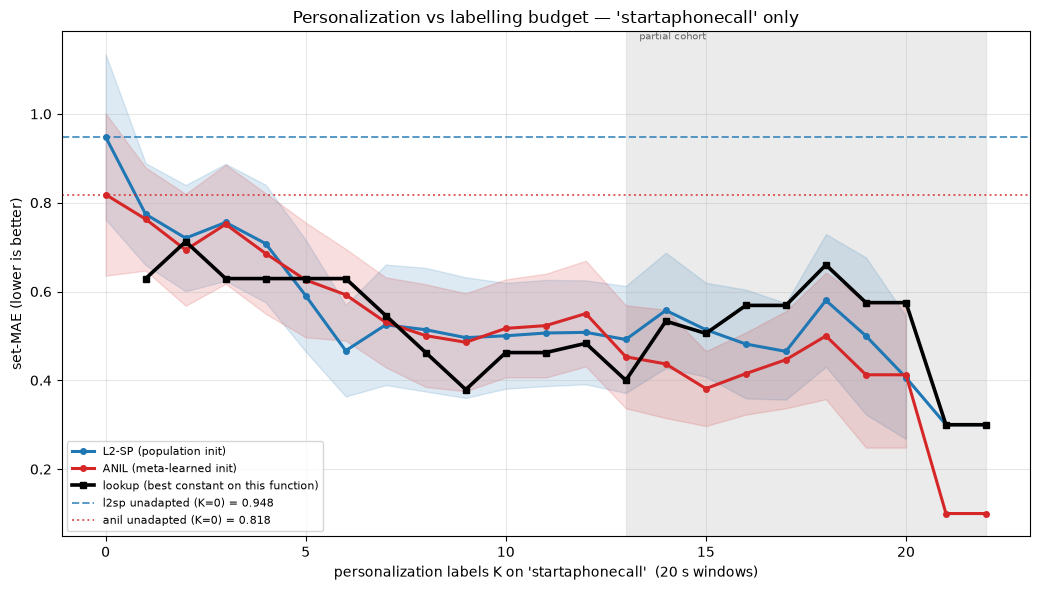

In [2]:
def curve(df, col):
    """mean, se and n over drivers at each K."""
    g = df.groupby("k")[col].agg(["mean", "std", "count"])
    g["se"] = g["std"] / np.sqrt(g["count"])
    return g


def draw(ax, col, ylabel, title, pids=None, legend=True,
         A_=None, LK_=None, ks=None, k_cap=None, xlabel=None):
    """The cohort figure, optionally restricted to `pids`.

    Floors are recomputed on whatever subset is passed -- carrying over the
    12-driver floor would compare a curve and a reference measured on different
    cohorts, which is the same error the shaded region warns about.

    ``A_``/``LK_``/``ks``/``k_cap`` default to the module-level function-scope
    tables. Passing the all-scope ones renders that run through THIS definition
    rather than a copy, so the two scopes cannot drift apart in styling, in the
    floor rule, or in what the shaded region means.
    """
    A_ = A if A_ is None else A_
    LK_ = LK if LK_ is None else LK_
    ks = KS if ks is None else ks
    k_cap = K_CAP if k_cap is None else k_cap
    sel = (lambda d: d if pids is None else d[d.pid.isin(pids)])
    for arm, label in ARMS.items():
        g = curve(sel(A_[arm]), col)
        ax.plot(g.index, g["mean"], color=COL[arm], lw=2.2, marker="o", ms=4, label=label)
        ax.fill_between(g.index, g["mean"] - g["se"], g["mean"] + g["se"],
                        color=COL[arm], alpha=.15)
    g = curve(sel(LK_), col)
    ax.plot(g.index, g["mean"], color=COL["lookup"], lw=2.6, marker="s", ms=4,
            label="lookup (best constant on this function)")
    for arm, ls in (("l2sp", "--"), ("anil", ":")):
        base = "base_set_mae" if col == "set_mae" else "base_set_acc"
        d_ = sel(A_[arm])
        if base in d_.columns:
            v = d_.groupby("pid")[base].first().mean()
        else:
            # No base_* column for this metric (set_acc). The K=0 rows
            # ARE the unadapted model, so read the floor off them
            # rather than dropping the reference line without saying so.
            z = d_[d_.k == 0]
            if z.empty:
                continue
            v = z.groupby("pid")[col].first().mean()
        ax.axhline(v, ls=ls, c=COL[arm], lw=1.4, alpha=.75,
                   label=f"{arm} unadapted (K=0) = {v:.3f}")
    if max(ks) > k_cap:
        ax.axvspan(k_cap, max(ks), color="0.85", alpha=.5, zorder=0)
        ax.text(k_cap * 1.02, ax.get_ylim()[1], " partial cohort", va="top",
                fontsize=7, color="0.4")
    ax.set_xlabel(xlabel or f"personalization labels K on {FUNC!r}  (20 s windows)")
    ax.set_ylabel(ylabel); ax.set_title(title); ax.grid(alpha=.3)
    if legend:
        ax.legend(fontsize=8)


fig, ax = plt.subplots(figsize=(10.5, 6))
draw(ax, "set_mae", "set-MAE (lower is better)",
     f"Personalization vs labelling budget — {FUNC!r} only")
plt.tight_layout(); save(fig, f"{FIGPREFIX}_k_curve_set_mae"); plt.show()

---
## 2. K curves in set-accuracy



[fig] C:\DATA\UCL\Asignaturas\TFM\MarkColley_Mercedes\ProActivity_Personalization\latex\figures\phonecall_k_curve_set_acc.pdf


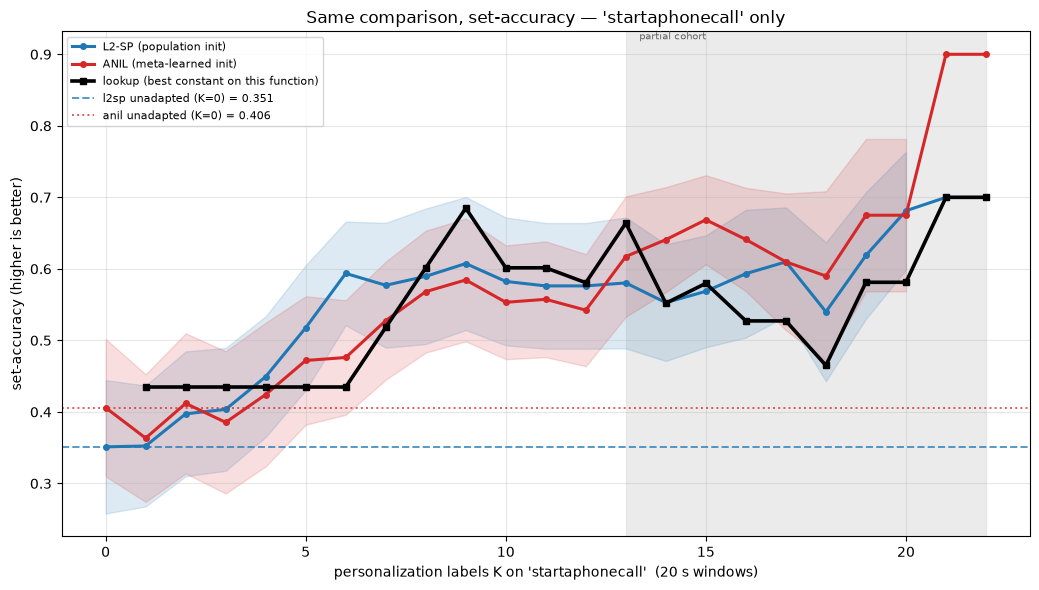

**Averaged within driver, then across drivers (1 &le; K &le; 13)**

,arm,set_mae,se,set_acc,n_drivers
0,L2-SP,0.5813,0.1120,0.5233,12
1,ANIL,0.5902,0.1064,0.4987,12
2,lookup,0.5426,0.1243,0.5278,12


K=0 is excluded: it is the unadapted floor, identical at every K within an arm,
so averaging it into a personalization curve dilutes the effect toward zero.


In [3]:
if "set_acc" in D.columns:
    fig, ax = plt.subplots(figsize=(10.5, 6))
    draw(ax, "set_acc", "set-accuracy (higher is better)",
         f"Same comparison, set-accuracy — {FUNC!r} only")
    plt.tight_layout(); save(fig, f"{FIGPREFIX}_k_curve_set_acc"); plt.show()

tbl = []
for name, df in [("L2-SP", A["l2sp"]), ("ANIL", A["anil"]), ("lookup", LK)]:
    sub = df[(df.k >= 1) & (df.k <= K_CAP)]
    pdm = sub.groupby("pid").set_mae.mean()
    pda = sub.groupby("pid").set_acc.mean()
    tbl.append({"arm": name, "set_mae": pdm.mean(),
                "se": pdm.std(ddof=1) / np.sqrt(len(pdm)),
                "set_acc": pda.mean(), "n_drivers": len(pdm)})
display(Markdown(f"**Averaged within driver, then across drivers (1 &le; K &le; {K_CAP})**"))
display(pd.DataFrame(tbl).round(4))
print("K=0 is excluded: it is the unadapted floor, identical at every K within an arm,")
print("so averaging it into a personalization curve dilutes the effect toward zero.")

---
## 3. Per-driver curves

The cohort mean hides that these drivers are not alike. On this slice the spread is
extreme — see section 7 — so the panels are the honest view.

Panels deliberately do **not** share a y-axis: per-driver difficulty spans most of the
metric's range, and a common scale would compress the majority into a band and hide the
within-driver movement these panels exist to show.

Expect ragged lines. At a 5–10 segment tail a single query segment changing its decoded
level moves set-MAE by 0.1–0.2, so these curves step rather than glide. That is the
resolution of the instrument, not driver behaviour.

[fig] C:\DATA\UCL\Asignaturas\TFM\MarkColley_Mercedes\ProActivity_Personalization\latex\figures\phonecall_per_driver_set_mae.pdf


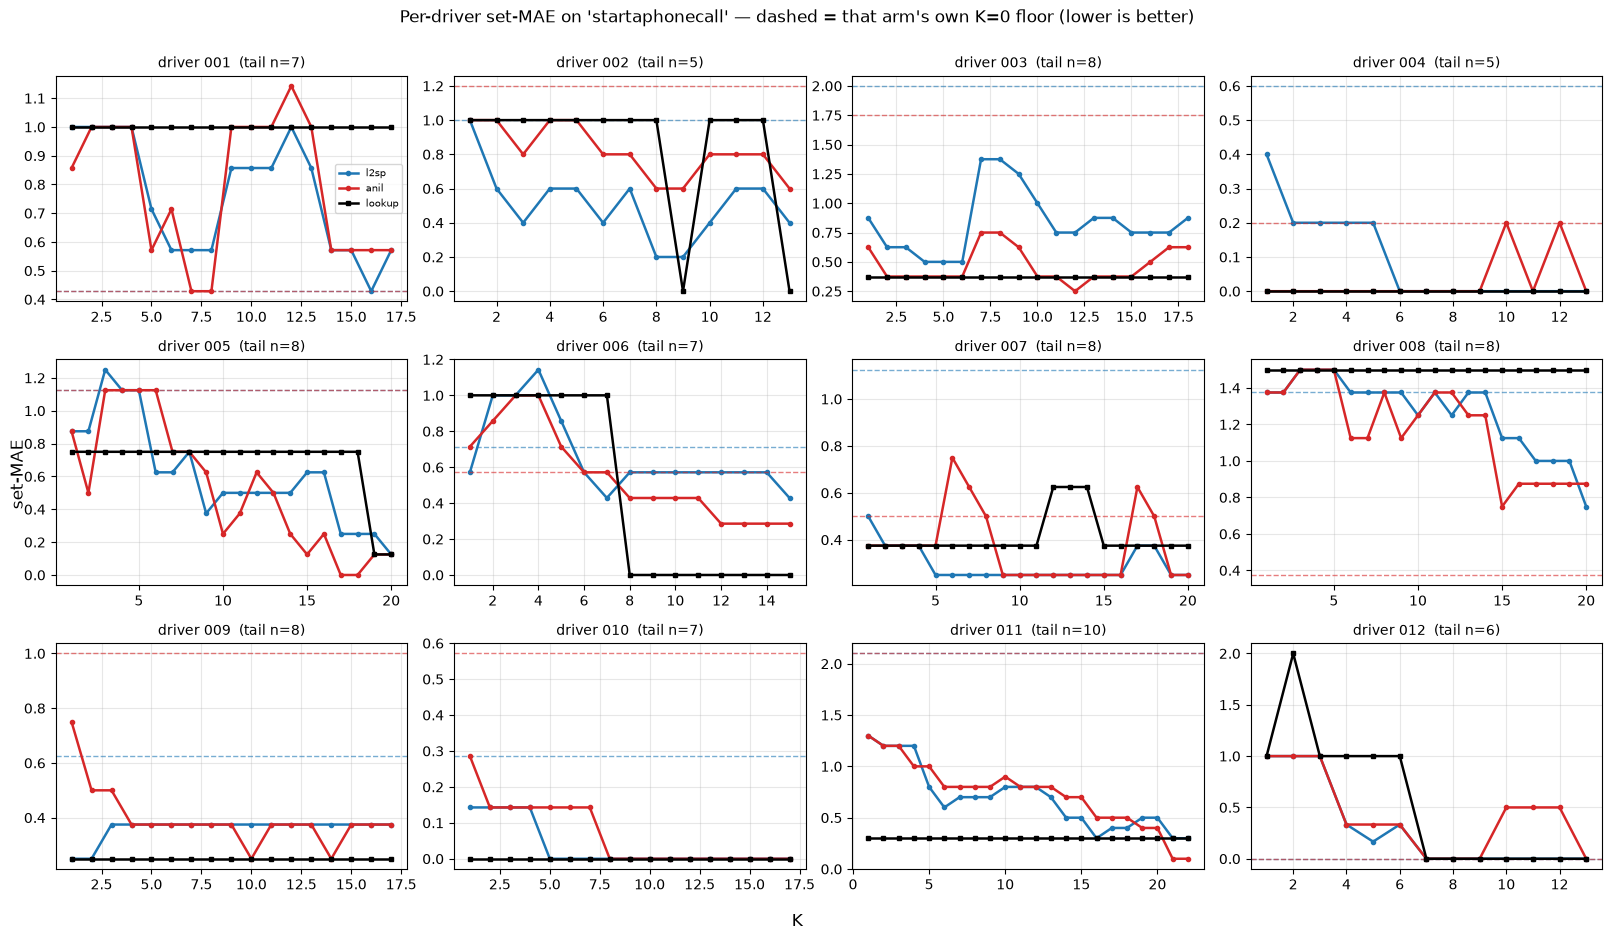

In [4]:
PIDS = sorted(A["l2sp"].pid.unique())


def per_driver_panels(col: str, base_col: str, ylabel: str, better: str,
                      pids=None, ncol: int = 4):
    """One panel per driver: both arms, the lookup, and each arm's OWN K=0 floor."""
    pids = list(pids if pids is not None else PIDS)
    nrow = int(np.ceil(len(pids) / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(4.1 * ncol, 3.1 * nrow), squeeze=False)
    flat = axes.ravel()
    for ax, pid in zip(flat, pids):
        for arm in ARMS:
            d = A[arm]
            g = d[(d.pid == pid) & (d.k >= 1)].sort_values("k")
            ax.plot(g.k, g[col], color=COL[arm], lw=1.8, marker="o", ms=3, label=arm)
            if base_col in d.columns:
                ax.axhline(g[base_col].iloc[0], ls="--", c=COL[arm], lw=1, alpha=.6)
        g = LK[LK.pid == pid].sort_values("k")
        ax.plot(g.k, g[col], color="k", lw=1.8, marker="s", ms=3, label="lookup")
        n_val = int(A["l2sp"][A["l2sp"].pid == pid].n_val.iloc[0])
        ax.set_title(f"driver {pid}  (tail n={n_val})", fontsize=10)
        ax.grid(alpha=.3)
    for ax in flat[len(pids):]:
        ax.axis("off")
    flat[0].legend(fontsize=7)
    fig.supxlabel("K"); fig.supylabel(ylabel)
    fig.suptitle(f"Per-driver {ylabel} on {FUNC!r} — dashed = that arm's own K=0 floor "
                 f"({better} is better)", y=1.0)
    plt.tight_layout()
    save(fig, f"{FIGPREFIX}_per_driver_{col}")
    plt.show()

per_driver_panels("set_mae", "base_set_mae", "set-MAE", "lower")


[fig] C:\DATA\UCL\Asignaturas\TFM\MarkColley_Mercedes\ProActivity_Personalization\latex\figures\phonecall_per_driver_set_acc.pdf


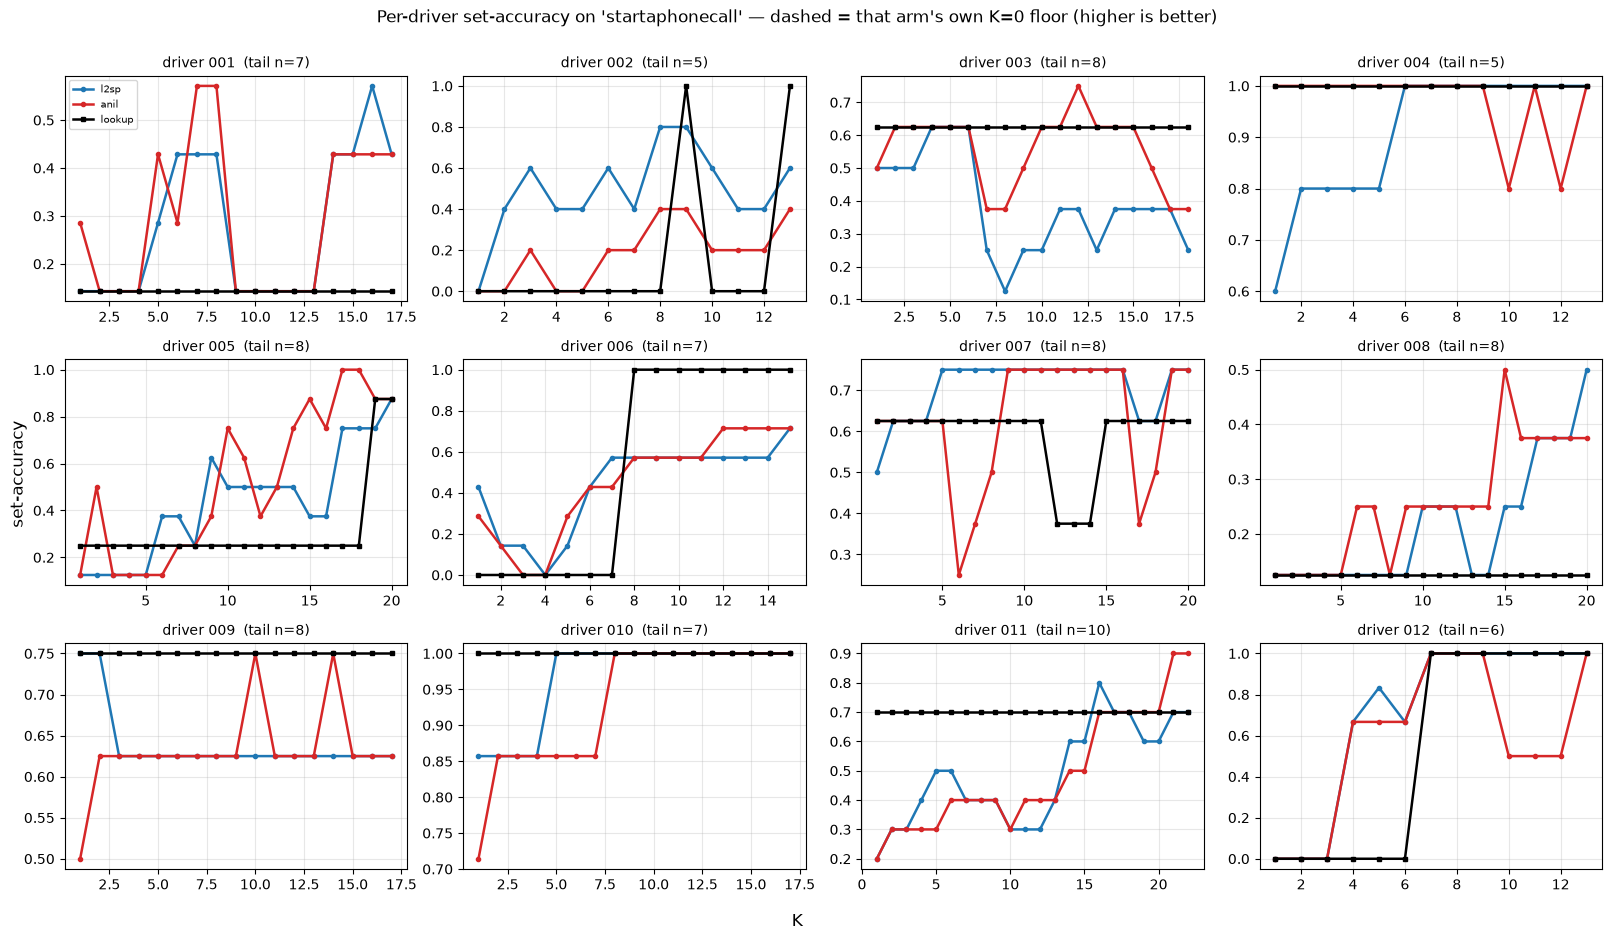

In [5]:
per_driver_panels("set_acc", "base_set_acc", "set-accuracy", "higher")


---
## 5. Support scope — must the labels be on the target function?

`phone_call_k_curve` was run twice against the **same** query rows, changing only
where the K adaptation labels come from (`--support-scope`):

* **`function`** (Section 1, and what shipped): the K labels are K *phone-call*
  labels. Pool sizes 13&ndash;22 per driver, so the cohort is complete only to
  K = 13.
* **`all`**: the K labels are drawn from every function. Pool sizes 71&ndash;101,
  so the curve runs much further.

The tails are identical driver by driver, so the two are directly comparable at
matched K: *is a phone-call label worth more than an arbitrary one?* The study
served function-scoped heads, so Section 1 remains the primary result and this is
the counterfactual.


tails identical across scopes (87 query segments); pool 13-22 (function) vs 71-101 (all)
[fig] C:\DATA\UCL\Asignaturas\TFM\MarkColley_Mercedes\ProActivity_Personalization\latex\figures\phonecall_allscope_k_curve_set_mae.pdf


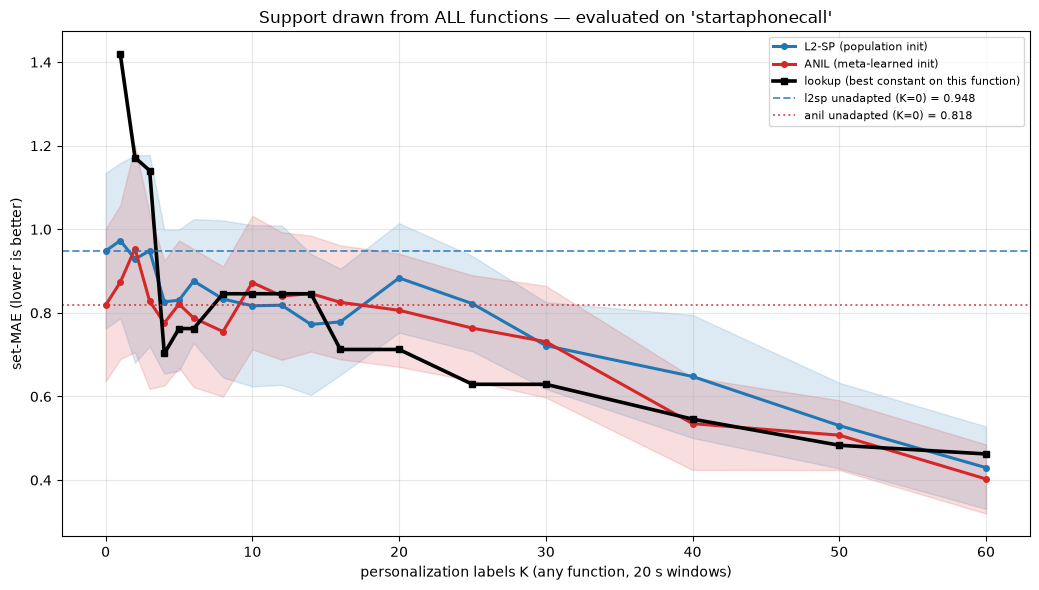

[fig] C:\DATA\UCL\Asignaturas\TFM\MarkColley_Mercedes\ProActivity_Personalization\latex\figures\phonecall_allscope_k_curve_set_acc.pdf


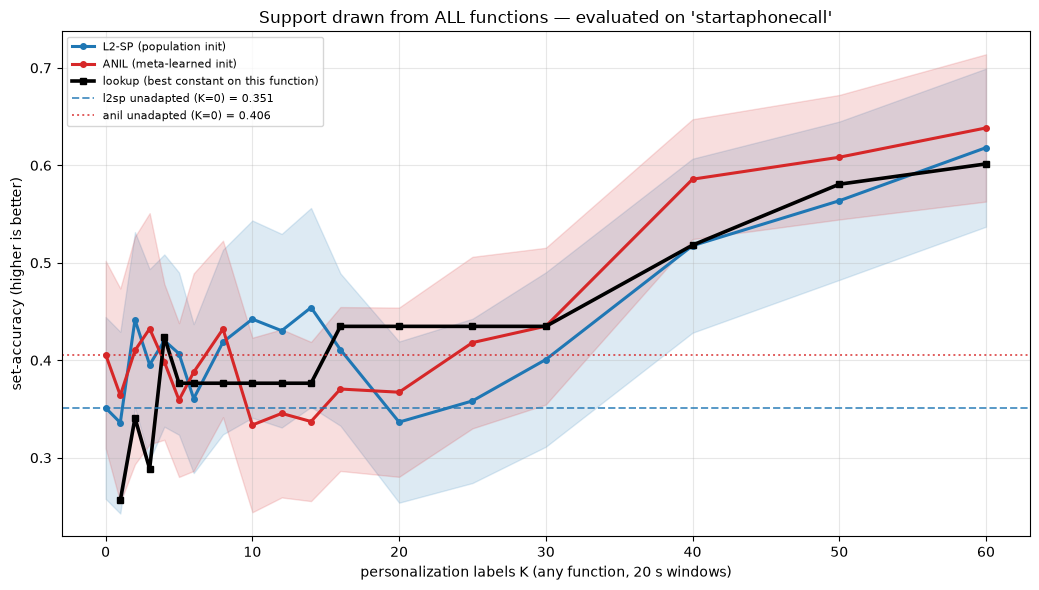

**All-scope minus function-scope set-MAE, matched on (driver, K) over K in [1, 2, 3, 4, 5, 6, 8, 10, 12, 14, 16, 20]** — positive means the function-scoped labels win

,arm,n_cells,all_minus_function,se,function_better_on
0,l2sp,129,0.2783,0.0589,66
1,anil,129,0.2510,0.0581,72


A positive value says a phone-call label is worth more than an arbitrary one
at the same K, which is what the deployed protocol assumes.


In [6]:
# ---- the all-scope run, drawn through the SAME `draw` as the function scope
ALL_DIR = pathlib.Path(os.environ.get("PCK_ALL_DIR", ROOT / "results/phone_call_k_curve_all"))
if not (ALL_DIR / "phone_call_k_curve.csv").exists():
    print(f"[skip] {ALL_DIR} not present — re-run with --support-scope all")
else:
    D_ALL = pd.read_csv(ALL_DIR / "phone_call_k_curve.csv", dtype={"pid": str})
    S_ALL = json.loads((ALL_DIR / "phone_call_k_curve.json").read_text(encoding="utf-8"))
    A_ALL = {a: D_ALL[D_ALL.arm == a].copy() for a in ARMS}
    LK_ALL = D_ALL[D_ALL.arm == "lookup"].copy()
    KS_ALL, KCAP_ALL = sorted(D_ALL.k.unique()), int(S_ALL["k_common"])

    # The contrast is only interpretable if the QUERY rows are the same; assert it
    # rather than trusting the two runs used one --val-frac.
    t_fn = A["l2sp"].groupby("pid").n_val.first()
    t_all = A_ALL["l2sp"].groupby("pid").n_val.first()
    assert t_fn.equals(t_all), "tails differ — the two scopes are not comparable"
    print(f"tails identical across scopes ({t_fn.sum()} query segments); "
          f"pool {A['l2sp'].groupby('pid').n_pool.first().min()}-"
          f"{A['l2sp'].groupby('pid').n_pool.first().max()} (function) vs "
          f"{A_ALL['l2sp'].groupby('pid').n_pool.first().min()}-"
          f"{A_ALL['l2sp'].groupby('pid').n_pool.first().max()} (all)")

    for col, ylab, tag in (("set_mae", "set-MAE (lower is better)", "set_mae"),
                           ("set_acc", "set-accuracy (higher is better)", "set_acc")):
        fig, ax = plt.subplots(figsize=(10.5, 6))
        draw(ax, col, ylab, f"Support drawn from ALL functions — evaluated on {FUNC!r}",
             A_=A_ALL, LK_=LK_ALL, ks=KS_ALL, k_cap=KCAP_ALL,
             xlabel="personalization labels K (any function, 20 s windows)")
        plt.tight_layout(); save(fig, f"{FIGPREFIX}_allscope_k_curve_{tag}"); plt.show()

    # Paired at matched K over the range both scopes cover. Same driver, same K,
    # same query rows -- the only difference is what the K labels were.
    shared = sorted(set(KS) & set(KS_ALL) - {0})
    rows = []
    for arm in ARMS:
        f_ = A[arm][A[arm].k.isin(shared)].set_index(["pid", "k"]).set_mae
        a_ = A_ALL[arm][A_ALL[arm].k.isin(shared)].set_index(["pid", "k"]).set_mae
        d = (a_ - f_.reindex(a_.index)).dropna()
        rows.append({"arm": arm, "n_cells": len(d), "all_minus_function": d.mean(),
                     "se": d.std(ddof=1) / np.sqrt(len(d)),
                     "function_better_on": int((d > 0).sum())})
    display(Markdown(f"**All-scope minus function-scope set-MAE, matched on (driver, K) "
                     f"over K in {shared}** — positive means the function-scoped labels win"))
    display(pd.DataFrame(rows).round(4))
    print("A positive value says a phone-call label is worth more than an arbitrary one\n"
          "at the same K, which is what the deployed protocol assumes.")
